# 03 — Baseline CNN: Bainite vs Martensite

## Robust and Explainable Steel Microstructure Classification

This notebook establishes the **deep-learning baseline** for the project using a custom convolutional neural network (CNN) trained from scratch in PyTorch.

Two experiments are performed with the same architecture and training procedure:

1. **Standard stratified split** — conventional in-domain benchmark.
2. **Sample-grouped split** — evaluates generalization to completely unseen physical samples (`SampleIDHarm`).

### Prediction target

- `0` → Bainite
- `1` → Martensite

### Why train a custom CNN first?

A pretrained ResNet may ultimately perform better, but a small CNN provides a transparent reference point. Later improvements from transfer learning and domain-robust methods can then be measured against a genuine from-scratch baseline.

### Metrics

We report:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- Macro-F1
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Learning Curves
- Class-wise report
- Prediction-confidence distribution
- Misclassified examples

> The microscope and magnification holdouts are intentionally reserved for later notebooks.


## 1. User configuration

These paths assume:

```text
AI_Materials_Microscopy/
├── data/
│   └── processed/
├── notebooks/
│   └── 03_baseline_cnn.ipynb
├── models/
└── results/
```

Normally you should not need to change them.


In [1]:
from pathlib import Path

BASELINE_MANIFEST = Path(r"../data/processed/split_baseline_stratified.csv")
GROUPED_MANIFEST = Path(r"../data/processed/split_sample_grouped.csv")

MODEL_DIR = Path(r"../models/03_baseline_cnn")
RESULT_DIR = Path(r"../results/03_baseline_cnn")

# Reproducibility
SEED = 42

# Image/training settings
IMAGE_SIZE = 128
BATCH_SIZE = 64
NUM_WORKERS = 0        # safest default for Windows + Jupyter
MAX_EPOCHS = 30
PATIENCE = 6
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Conservative augmentation: orientation changes only.
USE_AUGMENTATION = True


## 2. Imports

If PyTorch or scikit-learn is missing, install it in your environment before continuing. The notebook automatically uses CUDA when available and otherwise falls back to CPU.


In [2]:
import copy
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

from IPython.display import display

warnings.filterwarnings("ignore")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))


PyTorch version: 2.14.0+cpu
CUDA available : False


## 3. Reproducibility and device

Exact bit-for-bit reproducibility can vary across hardware/library versions, but fixed seeds and deterministic settings reduce avoidable variation.


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducibility-oriented settings.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 4. Load and validate split manifests


In [4]:
assert BASELINE_MANIFEST.exists(), (
    f"Missing baseline manifest: {BASELINE_MANIFEST.resolve()}\n"
    "Run Notebook 02 first."
)
assert GROUPED_MANIFEST.exists(), (
    f"Missing grouped manifest: {GROUPED_MANIFEST.resolve()}\n"
    "Run Notebook 02 first."
)

baseline_df = pd.read_csv(BASELINE_MANIFEST)
grouped_df = pd.read_csv(GROUPED_MANIFEST)

required = {"image_path", "Phase", "label", "split"}

for name, df in [("baseline", baseline_df), ("sample_grouped", grouped_df)]:
    missing = required - set(df.columns)
    assert not missing, f"{name}: missing columns {missing}"
    assert set(df["split"].unique()) == {"train", "val", "test"}
    assert set(df["label"].unique()) == {0, 1}

    missing_files = [p for p in df["image_path"] if not Path(p).exists()]
    assert not missing_files, (
        f"{name}: {len(missing_files)} image files cannot be found.\n"
        "If the project was moved after Notebook 02, rerun Notebook 02 "
        "so image_path values are regenerated."
    )

print("Baseline manifest:", baseline_df.shape)
display(pd.crosstab(baseline_df["split"], baseline_df["Phase"], margins=True))

print("\nSample-grouped manifest:", grouped_df.shape)
display(pd.crosstab(grouped_df["split"], grouped_df["Phase"], margins=True))


Baseline manifest: (5293, 14)


Phase,Bainite,Martensite,All
split,,,
test,371,423,794
train,1729,1976,3705
val,370,424,794
All,2470,2823,5293



Sample-grouped manifest: (5293, 14)


Phase,Bainite,Martensite,All
split,,,
test,342,418,760
train,1786,2025,3811
val,342,380,722
All,2470,2823,5293


## 5. Confirm sample separation

The standard baseline is expected to contain sample overlap. The grouped experiment must have **zero physical-sample overlap**.


In [5]:
def split_values(df, split, column):
    return set(df.loc[df["split"] == split, column])

if "SampleIDHarm" in grouped_df.columns:
    g_train = split_values(grouped_df, "train", "SampleIDHarm")
    g_val = split_values(grouped_df, "val", "SampleIDHarm")
    g_test = split_values(grouped_df, "test", "SampleIDHarm")

    assert not (g_train & g_val)
    assert not (g_train & g_test)
    assert not (g_val & g_test)

    print("✓ Sample-grouped split has zero SampleIDHarm overlap.")
    print("Train samples:", sorted(g_train))
    print("Val samples  :", sorted(g_val))
    print("Test samples :", sorted(g_test))


✓ Sample-grouped split has zero SampleIDHarm overlap.
Train samples: ['A', 'C', 'D', 'E', 'G', 'H', 'J', 'M', 'N', 'P', 'Q', 'R', 'S', 'T']
Val samples  : ['I', 'L', 'O']
Test samples : ['B', 'F', 'K']


# Part A — Image preprocessing

All images are resized to a common `128 × 128` resolution.

For the baseline, training augmentation is deliberately conservative:

- random horizontal flip,
- random vertical flip.

These transformations change orientation without deliberately altering texture, contrast, or scale. More aggressive domain-robust augmentation will be investigated later.

Images are converted to tensors and normalized using simple `[0.5, 0.5, 0.5]` channel statistics. Notebook 04 can test pretrained-model-specific normalization.


In [6]:
train_transform_steps = [
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
]

if USE_AUGMENTATION:
    train_transform_steps += [
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
    ]

train_transform_steps += [
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    ),
]

eval_transform_steps = [
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    ),
]

train_transform = transforms.Compose(train_transform_steps)
eval_transform = transforms.Compose(eval_transform_steps)

print(train_transform)


Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


## 6. PyTorch Dataset


In [7]:
class MicrostructureDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        with Image.open(row["image_path"]) as img:
            image = img.convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(int(row["label"]), dtype=torch.long)

        return image, label, idx


## 7. DataLoader factory

Training data are shuffled; validation and test data are not.


In [8]:
def make_loaders(df):
    train_df = df[df["split"] == "train"].copy()
    val_df = df[df["split"] == "val"].copy()
    test_df = df[df["split"] == "test"].copy()

    train_ds = MicrostructureDataset(train_df, train_transform)
    val_ds = MicrostructureDataset(val_df, eval_transform)
    test_ds = MicrostructureDataset(test_df, eval_transform)

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    return {
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "train_ds": train_ds,
        "val_ds": val_ds,
        "test_ds": test_ds,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
    }


## 8. Visual sanity check after preprocessing


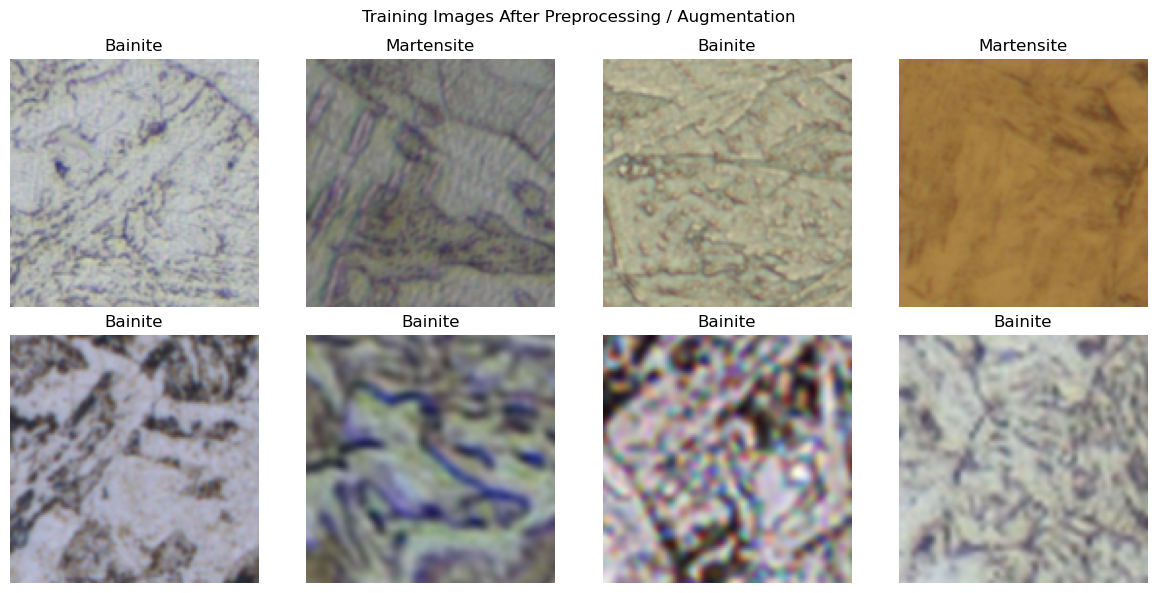

In [9]:
preview = make_loaders(baseline_df)
images_batch, labels_batch, _ = next(iter(preview["train_loader"]))

def denormalize(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i, ax in enumerate(axes):
    img = denormalize(images_batch[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title("Bainite" if labels_batch[i].item() == 0 else "Martensite")
    ax.axis("off")

fig.suptitle("Training Images After Preprocessing / Augmentation")
fig.tight_layout()
plt.show()

del preview, images_batch, labels_batch


# Part B — Custom CNN

The network is intentionally modest:

`RGB image → Conv blocks → Adaptive Average Pooling → Fully Connected classifier`

Batch normalization stabilizes optimization and dropout provides regularization.

This is **not intended to be the final architecture**. It is our from-scratch reference model.


In [10]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model_check = BaselineCNN().to(device)

n_params = sum(p.numel() for p in model_check.parameters())
n_trainable = sum(p.numel() for p in model_check.parameters() if p.requires_grad)

print(model_check)
print(f"\nTotal parameters    : {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

del model_check


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm

# Part C — Training utilities

Model selection uses **validation macro-F1**, not test performance.

The test set is evaluated only after training has finished and the best validation checkpoint has been restored.


In [11]:
def compute_basic_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    y_true, y_pred, y_prob, row_indices = [], [], [], []

    for inputs, labels, indices in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(inputs)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)

        total_loss += loss.item() * inputs.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())
        row_indices.extend(indices.numpy())

    metrics = compute_basic_metrics(y_true, y_pred, y_prob)
    metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, np.array(y_true), np.array(y_pred), np.array(y_prob), np.array(row_indices)


In [12]:
def train_one_experiment(experiment_name, dataframe):
    print("=" * 78)
    print("EXPERIMENT:", experiment_name)
    print("=" * 78)

    set_seed(SEED)
    bundle = make_loaders(dataframe)

    model = BaselineCNN().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    history = []
    best_f1 = -np.inf
    best_state = None
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        running_loss = 0.0
        train_true, train_pred, train_prob = [], [], []

        for inputs, labels, _ in bundle["train_loader"]:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(inputs)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            running_loss += loss.item() * inputs.size(0)
            train_true.extend(labels.detach().cpu().numpy())
            train_pred.extend(preds.detach().cpu().numpy())
            train_prob.extend(probs.detach().cpu().numpy())

        train_metrics = compute_basic_metrics(
            train_true, train_pred, train_prob
        )
        train_metrics["loss"] = running_loss / len(bundle["train_ds"])

        val_metrics, *_ = evaluate_loader(
            model, bundle["val_loader"], criterion
        )

        scheduler.step(val_metrics["f1_macro"])

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "lr": current_lr,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train loss {train_metrics['loss']:.4f} | "
            f"train F1 {train_metrics['f1_macro']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} | "
            f"val F1 {val_metrics['f1_macro']:.4f} | "
            f"val acc {val_metrics['accuracy']:.4f} | "
            f"lr {current_lr:.2e}"
        )

        if val_metrics["f1_macro"] > best_f1 + 1e-4:
            best_f1 = val_metrics["f1_macro"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly stopping after epoch {epoch}.")
            break

    elapsed = time.time() - start_time

    assert best_state is not None
    model.load_state_dict(best_state)

    checkpoint_path = MODEL_DIR / f"{experiment_name}_best.pt"
    torch.save({
        "model_state_dict": best_state,
        "architecture": "BaselineCNN",
        "image_size": IMAGE_SIZE,
        "label_map": {"Bainite": 0, "Martensite": 1},
        "seed": SEED,
        "best_val_macro_f1": float(best_f1),
    }, checkpoint_path)

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        RESULT_DIR / f"{experiment_name}_history.csv",
        index=False
    )

    test_metrics, y_true, y_pred, y_prob, row_indices = evaluate_loader(
        model, bundle["test_loader"], criterion
    )

    print(f"\nTraining time: {elapsed/60:.2f} minutes")
    print("Best validation macro-F1:", round(best_f1, 4))
    print("\nTEST METRICS")
    for k, v in test_metrics.items():
        print(f"{k:20s}: {v:.4f}")

    return {
        "name": experiment_name,
        "model": model,
        "bundle": bundle,
        "history": history_df,
        "test_metrics": test_metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "row_indices": row_indices,
        "checkpoint_path": checkpoint_path,
    }


# Part D — Experiment 1: Standard stratified baseline

This establishes the conventional in-domain reference performance.

Because physical samples overlap across splits, these results should **not** be described as performance on unseen specimens.


In [13]:
standard_result = train_one_experiment(
    experiment_name="standard_stratified",
    dataframe=baseline_df,
)


EXPERIMENT: standard_stratified
Epoch 01/30 | train loss 0.6685 | train F1 0.5963 | val loss 0.6893 | val F1 0.5416 | val acc 0.5970 | lr 1.00e-03
Epoch 02/30 | train loss 0.6209 | train F1 0.6440 | val loss 0.5869 | val F1 0.6771 | val acc 0.6776 | lr 1.00e-03
Epoch 03/30 | train loss 0.6024 | train F1 0.6562 | val loss 0.5909 | val F1 0.6536 | val acc 0.6537 | lr 1.00e-03
Epoch 04/30 | train loss 0.5901 | train F1 0.6779 | val loss 0.6351 | val F1 0.6550 | val acc 0.6574 | lr 1.00e-03
Epoch 05/30 | train loss 0.5811 | train F1 0.6790 | val loss 0.5969 | val F1 0.6445 | val acc 0.6461 | lr 5.00e-04
Epoch 06/30 | train loss 0.5475 | train F1 0.7168 | val loss 0.5764 | val F1 0.6867 | val acc 0.6902 | lr 5.00e-04
Epoch 07/30 | train loss 0.5449 | train F1 0.7215 | val loss 0.5194 | val F1 0.7420 | val acc 0.7431 | lr 5.00e-04
Epoch 08/30 | train loss 0.5330 | train F1 0.7289 | val loss 0.5692 | val F1 0.6865 | val acc 0.7128 | lr 5.00e-04
Epoch 09/30 | train loss 0.5225 | train F1 0.736

## 9. Standard baseline learning curves


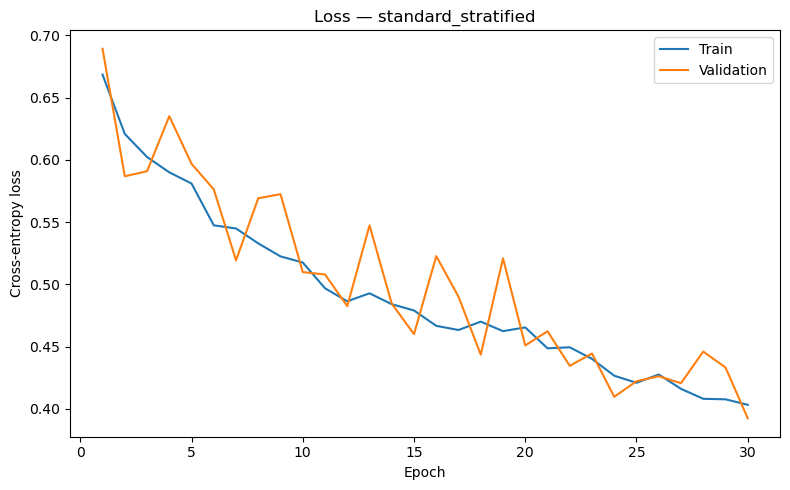

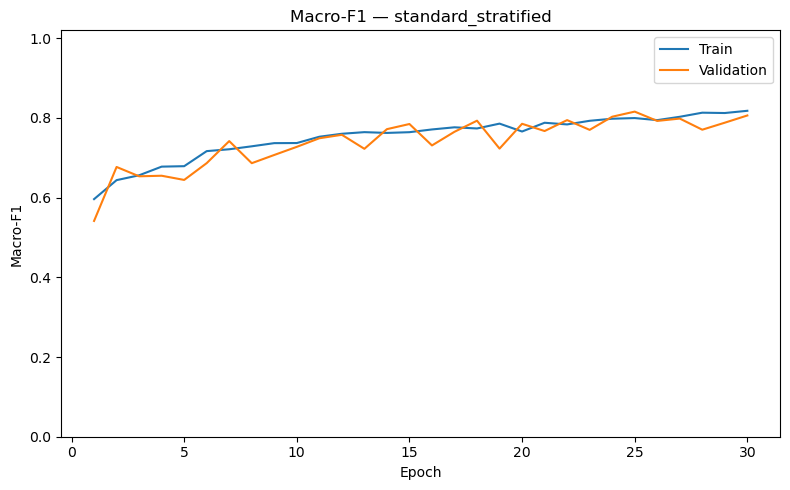

In [14]:
def plot_learning_curves(result):
    h = result["history"]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(h["epoch"], h["train_loss"], label="Train")
    ax.plot(h["epoch"], h["val_loss"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_title(f"Loss — {result['name']}")
    ax.legend()
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(h["epoch"], h["train_f1_macro"], label="Train")
    ax.plot(h["epoch"], h["val_f1_macro"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro-F1")
    ax.set_ylim(0, 1.02)
    ax.set_title(f"Macro-F1 — {result['name']}")
    ax.legend()
    fig.tight_layout()
    plt.show()

plot_learning_curves(standard_result)


# Part E — Experiment 2: Unseen physical samples

The same CNN architecture, preprocessing, optimizer, and training logic are now applied to the **sample-grouped split**.

This is the more scientifically meaningful specimen-generalization benchmark.


In [15]:
grouped_result = train_one_experiment(
    experiment_name="sample_grouped",
    dataframe=grouped_df,
)


EXPERIMENT: sample_grouped
Epoch 01/30 | train loss 0.6487 | train F1 0.6193 | val loss 0.7080 | val F1 0.5452 | val acc 0.5471 | lr 1.00e-03
Epoch 02/30 | train loss 0.6018 | train F1 0.6606 | val loss 0.7269 | val F1 0.5401 | val acc 0.5402 | lr 1.00e-03
Epoch 03/30 | train loss 0.5735 | train F1 0.6909 | val loss 0.6839 | val F1 0.6042 | val acc 0.6080 | lr 1.00e-03
Epoch 04/30 | train loss 0.5713 | train F1 0.7027 | val loss 0.6983 | val F1 0.6115 | val acc 0.6191 | lr 1.00e-03
Epoch 05/30 | train loss 0.5612 | train F1 0.7030 | val loss 0.7200 | val F1 0.5779 | val acc 0.6219 | lr 1.00e-03
Epoch 06/30 | train loss 0.5483 | train F1 0.7112 | val loss 0.7077 | val F1 0.5691 | val acc 0.6080 | lr 1.00e-03
Epoch 07/30 | train loss 0.5350 | train F1 0.7240 | val loss 0.6997 | val F1 0.6058 | val acc 0.6122 | lr 5.00e-04
Epoch 08/30 | train loss 0.5096 | train F1 0.7446 | val loss 0.7513 | val F1 0.6161 | val acc 0.6427 | lr 5.00e-04
Epoch 09/30 | train loss 0.5021 | train F1 0.7390 | v

## 10. Sample-grouped learning curves


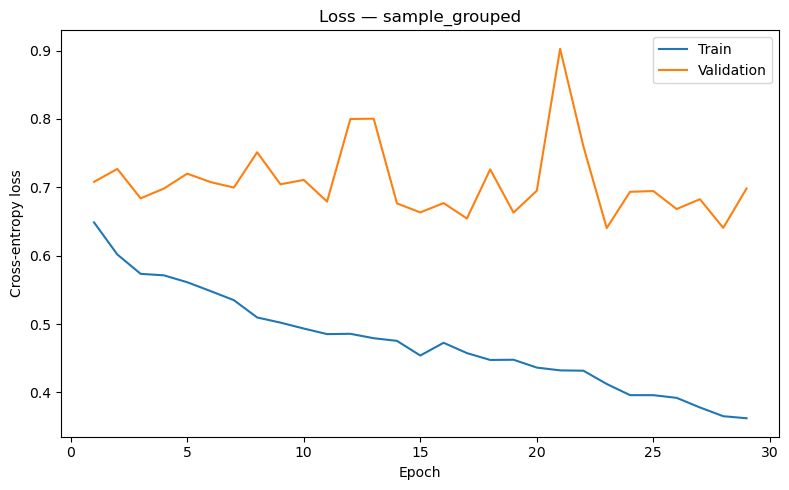

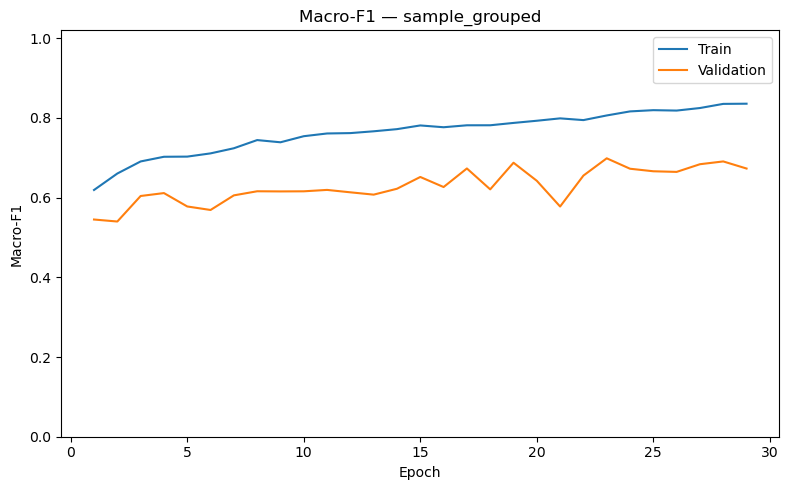

In [16]:
plot_learning_curves(grouped_result)


# Part F — Detailed evaluation

The following functions generate confusion matrices, ROC curves, classification reports, confidence distributions, and misclassified examples.


STANDARD_STRATIFIED

Classification report:
              precision    recall  f1-score   support

     Bainite     0.7822    0.7358    0.7583       371
  Martensite     0.7798    0.8203    0.7995       423

    accuracy                         0.7809       794
   macro avg     0.7810    0.7781    0.7789       794
weighted avg     0.7809    0.7809    0.7803       794



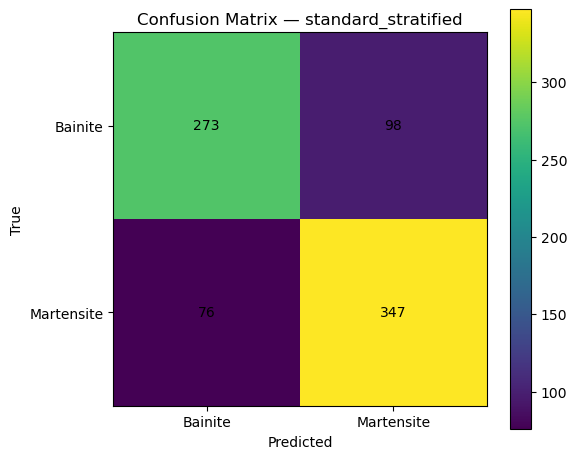

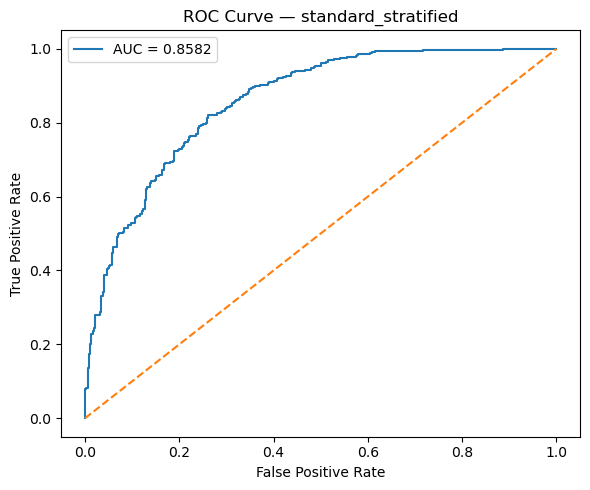

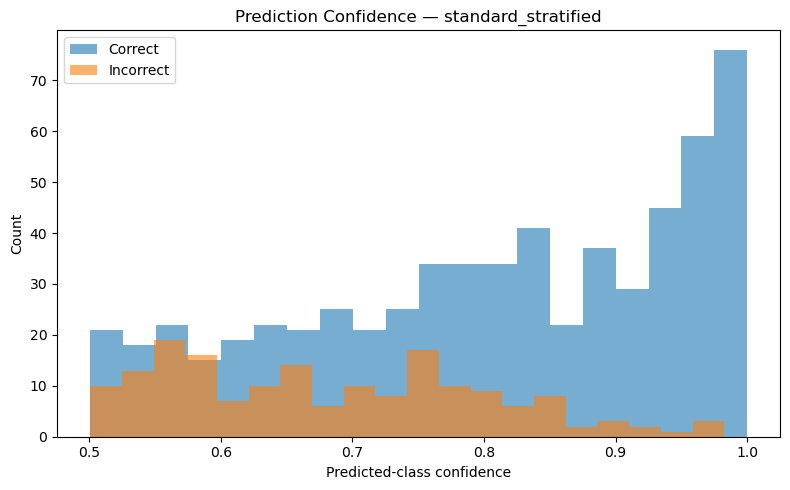

SAMPLE_GROUPED

Classification report:
              precision    recall  f1-score   support

     Bainite     0.6238    0.5526    0.5860       342
  Martensite     0.6652    0.7273    0.6949       418

    accuracy                         0.6487       760
   macro avg     0.6445    0.6400    0.6405       760
weighted avg     0.6466    0.6487    0.6459       760



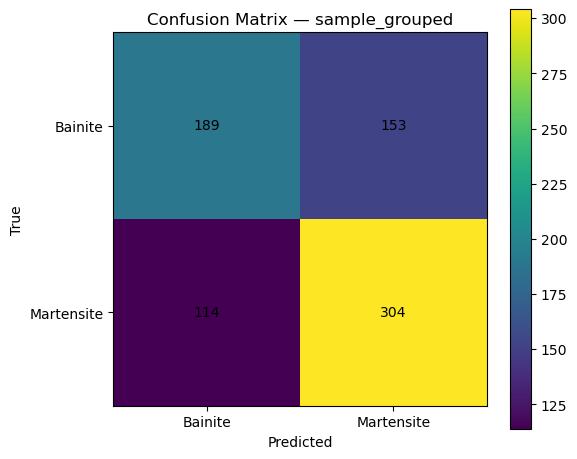

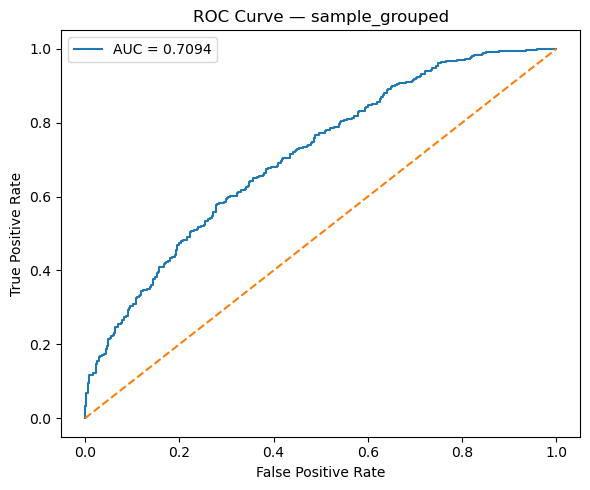

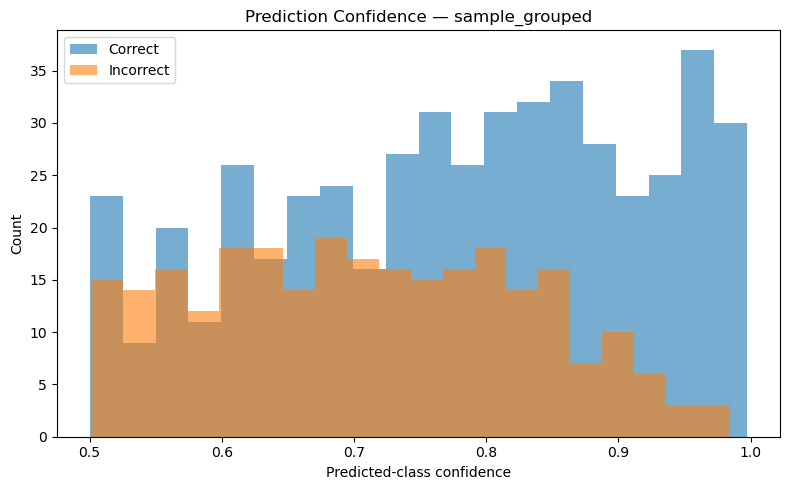

In [17]:
CLASS_NAMES = ["Bainite", "Martensite"]

def detailed_evaluation(result):
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    y_prob = result["y_prob"]

    print("=" * 70)
    print(result["name"].upper())
    print("=" * 70)

    print("\nClassification report:")
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    print(report)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1], CLASS_NAMES)
    ax.set_yticks([0, 1], CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix — {result['name']}")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {result['name']}")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # Confidence
    confidence = np.where(y_pred == 1, y_prob, 1 - y_prob)
    correct = y_pred == y_true

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(confidence[correct], bins=20, alpha=0.6, label="Correct")
    ax.hist(confidence[~correct], bins=20, alpha=0.6, label="Incorrect")
    ax.set_xlabel("Predicted-class confidence")
    ax.set_ylabel("Count")
    ax.set_title(f"Prediction Confidence — {result['name']}")
    ax.legend()
    fig.tight_layout()
    plt.show()

detailed_evaluation(standard_result)
detailed_evaluation(grouped_result)


## 11. Inspect misclassified microscopy images

This is useful for identifying whether errors are associated with ambiguous morphology, image quality, acquisition conditions, or particular samples.

The displayed examples are selected from the most confident wrong predictions, which are especially informative for later error analysis.


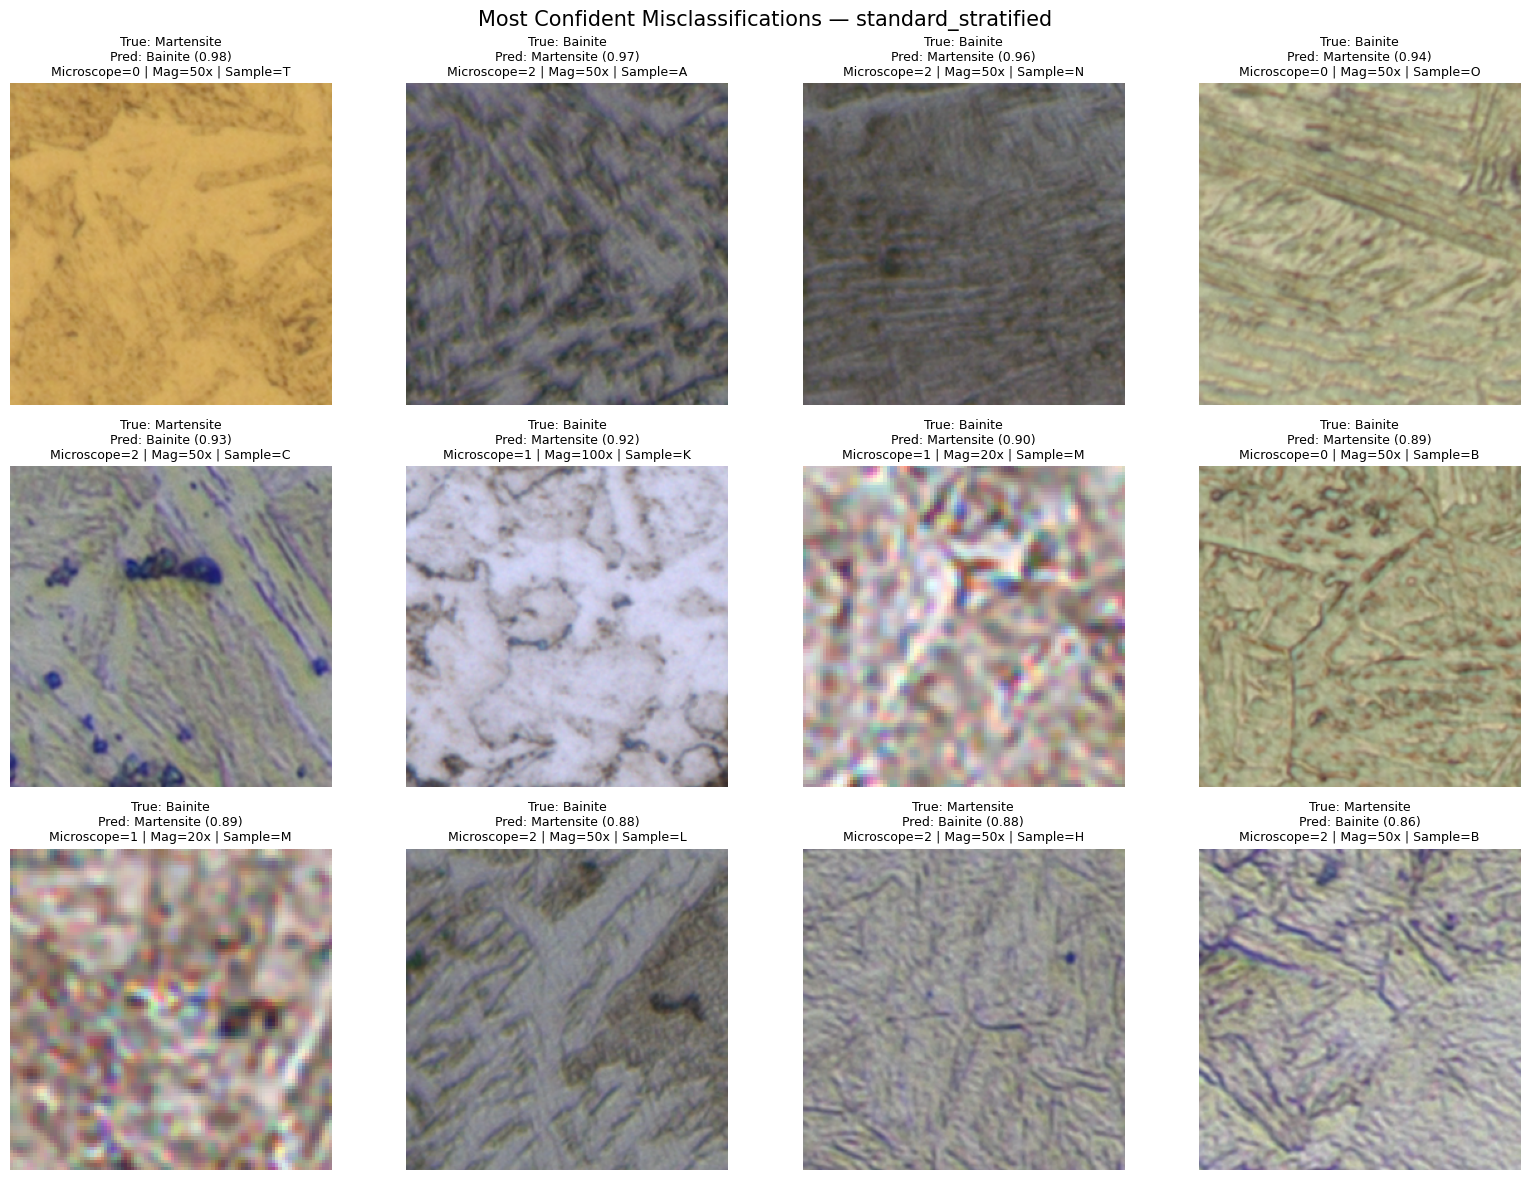

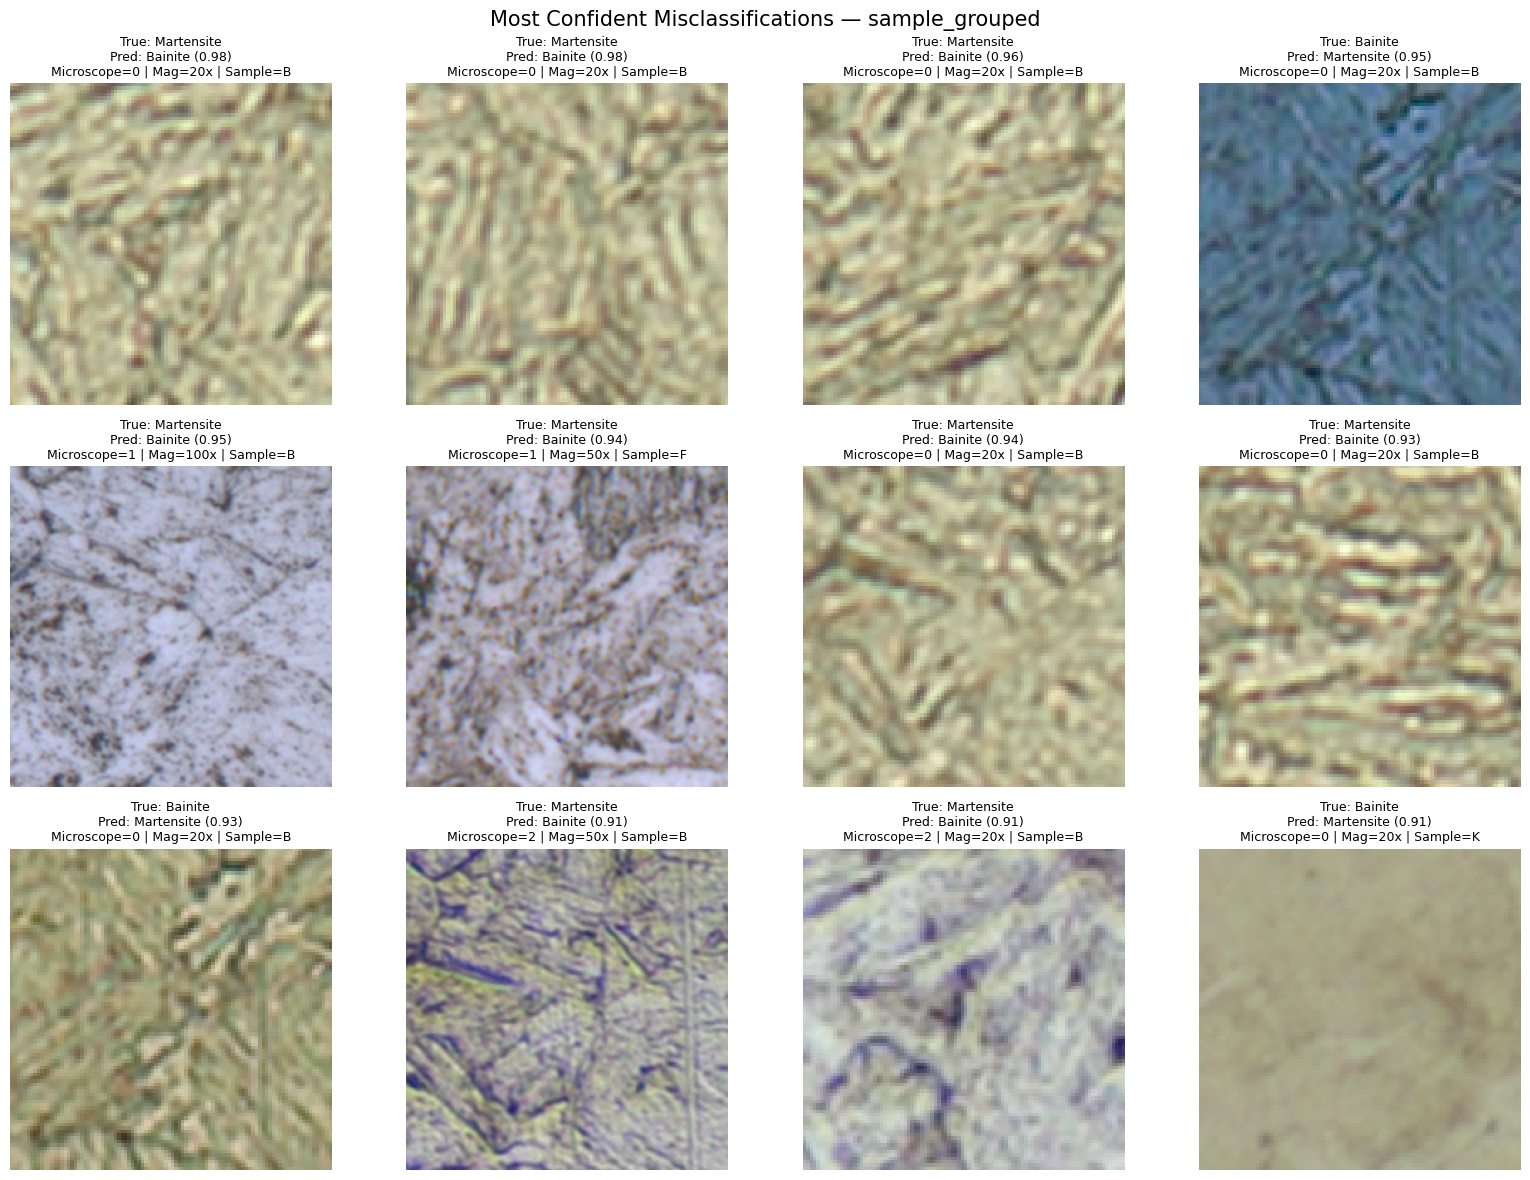

In [18]:
def show_misclassifications(result, n=12):
    test_df = result["bundle"]["test_df"].reset_index(drop=True).copy()

    pred_df = pd.DataFrame({
        "dataset_index": result["row_indices"],
        "true": result["y_true"],
        "pred": result["y_pred"],
        "p_martensite": result["y_prob"],
    })

    pred_df["confidence"] = np.where(
        pred_df["pred"] == 1,
        pred_df["p_martensite"],
        1 - pred_df["p_martensite"],
    )

    wrong = pred_df[pred_df["true"] != pred_df["pred"]].copy()
    wrong = wrong.sort_values("confidence", ascending=False).head(n)

    if wrong.empty:
        print("No misclassifications.")
        return

    ncols = 4
    nrows = int(np.ceil(len(wrong) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, pred_row) in zip(axes, wrong.iterrows()):
        row = test_df.iloc[int(pred_row["dataset_index"])]

        with Image.open(row["image_path"]) as img:
            ax.imshow(img.convert("RGB"))

        true_name = CLASS_NAMES[int(pred_row["true"])]
        pred_name = CLASS_NAMES[int(pred_row["pred"])]

        subtitle = ""
        if "MicroscopeID" in row.index:
            subtitle += f"\nMicroscope={row['MicroscopeID']}"
        if "Magnification" in row.index:
            subtitle += f" | Mag={row['Magnification']}"
        if "SampleIDHarm" in row.index:
            subtitle += f" | Sample={row['SampleIDHarm']}"

        ax.set_title(
            f"True: {true_name}\nPred: {pred_name} "
            f"({pred_row['confidence']:.2f}){subtitle}",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[len(wrong):]:
        ax.axis("off")

    fig.suptitle(
        f"Most Confident Misclassifications — {result['name']}",
        fontsize=15,
    )
    fig.tight_layout()
    plt.show()

show_misclassifications(standard_result)
show_misclassifications(grouped_result)


# Part G — Direct baseline comparison

The generalization gap between the standard split and unseen-sample split is one of the first substantive findings of the project.


In [19]:
comparison_rows = []

for result, evaluation in [
    (standard_result, "Standard stratified"),
    (grouped_result, "Unseen physical samples"),
]:
    m = result["test_metrics"]

    comparison_rows.append({
        "Model": "Custom CNN",
        "Evaluation": evaluation,
        "Accuracy": m["accuracy"],
        "Balanced Accuracy": m["balanced_accuracy"],
        "Macro Precision": m["precision_macro"],
        "Macro Recall": m["recall_macro"],
        "Macro F1": m["f1_macro"],
        "ROC-AUC": m["roc_auc"],
    })

comparison = pd.DataFrame(comparison_rows)

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
    })
)

comparison.to_csv(
    RESULT_DIR / "baseline_comparison.csv",
    index=False
)


,Model,Evaluation,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC
0,Custom CNN,Standard stratified,0.7809,0.7781,0.7810,0.7781,0.7789,0.8582
1,Custom CNN,Unseen physical samples,0.6487,0.6400,0.6445,0.6400,0.6405,0.7094


## 12. Visualize the generalization gap


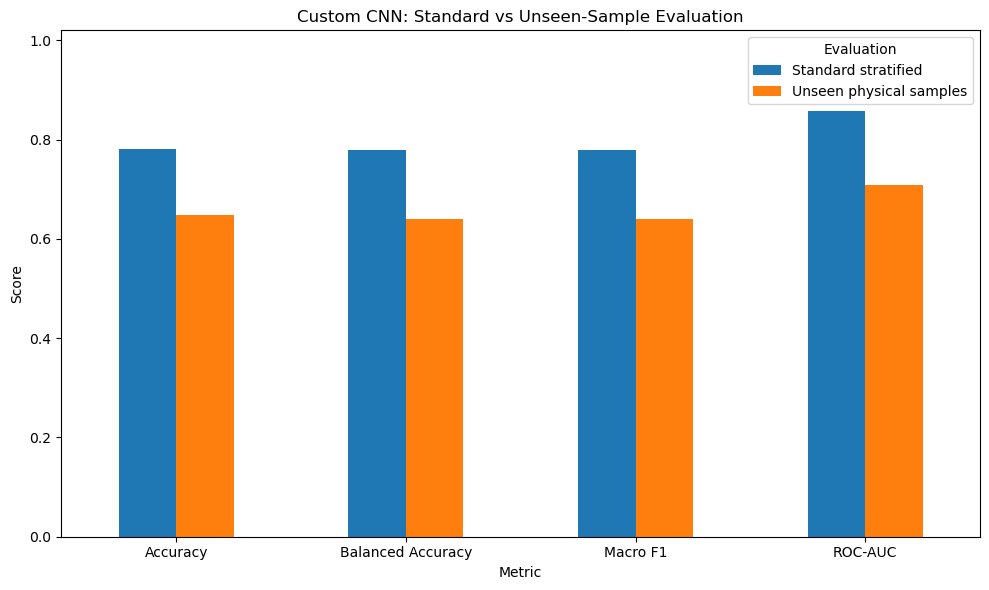

Macro-F1 difference (standard − unseen samples): +0.1385


In [20]:
metrics_to_plot = ["Accuracy", "Balanced Accuracy", "Macro F1", "ROC-AUC"]

plot_df = comparison.set_index("Evaluation")[metrics_to_plot].T

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.set_title("Custom CNN: Standard vs Unseen-Sample Evaluation")
ax.legend(title="Evaluation")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

standard_f1 = comparison.loc[
    comparison["Evaluation"] == "Standard stratified", "Macro F1"
].iloc[0]

grouped_f1 = comparison.loc[
    comparison["Evaluation"] == "Unseen physical samples", "Macro F1"
].iloc[0]

print(
    f"Macro-F1 difference (standard − unseen samples): "
    f"{standard_f1 - grouped_f1:+.4f}"
)


# Part H — Save prediction-level results

Prediction-level CSVs allow later error analysis by sample, microscope, and magnification without retraining the CNN.


In [21]:
def save_predictions(result):
    test_df = result["bundle"]["test_df"].reset_index(drop=True).copy()

    preds = pd.DataFrame({
        "dataset_index": result["row_indices"],
        "true_label": result["y_true"],
        "predicted_label": result["y_pred"],
        "p_martensite": result["y_prob"],
    })

    preds["true_phase"] = preds["true_label"].map(
        {0: "Bainite", 1: "Martensite"}
    )
    preds["predicted_phase"] = preds["predicted_label"].map(
        {0: "Bainite", 1: "Martensite"}
    )

    metadata_rows = test_df.iloc[preds["dataset_index"]].reset_index(drop=True)

    keep = [
        c for c in [
            "image_path",
            "filename",
            "SampleIDHarm",
            "MicroscopeID",
            "Magnification",
            "PatchID",
        ]
        if c in metadata_rows.columns
    ]

    output = pd.concat(
        [metadata_rows[keep].reset_index(drop=True), preds.reset_index(drop=True)],
        axis=1,
    )

    path = RESULT_DIR / f"{result['name']}_test_predictions.csv"
    output.to_csv(path, index=False)

    print("Saved:", path)

save_predictions(standard_result)
save_predictions(grouped_result)


Saved: ..\results\03_baseline_cnn\standard_stratified_test_predictions.csv
Saved: ..\results\03_baseline_cnn\sample_grouped_test_predictions.csv


# 13. Final experiment summary

Interpret the results conservatively:

- The **standard split** measures in-domain classification under a conventional random stratification.
- The **sample-grouped split** measures transfer to physical samples absent during training.
- A performance drop on unseen samples is evidence of a generalization challenge, not automatically evidence that the model is poor.
- Do not attribute the gap to a specific physical cause until error analysis supports that interpretation.


In [22]:
print("=" * 78)
print("BASELINE CNN SUMMARY")
print("=" * 78)

for _, row in comparison.iterrows():
    print(f"\n{row['Evaluation']}")
    print(f"  Accuracy          : {row['Accuracy']:.4f}")
    print(f"  Balanced Accuracy : {row['Balanced Accuracy']:.4f}")
    print(f"  Macro-F1          : {row['Macro F1']:.4f}")
    print(f"  ROC-AUC           : {row['ROC-AUC']:.4f}")

print("\nSaved checkpoints:")
print(" •", standard_result["checkpoint_path"])
print(" •", grouped_result["checkpoint_path"])

print("\nNEXT NOTEBOOK")
print(
    "04_transfer_learning.ipynb will use a pretrained ResNet18 "
    "and compare transfer learning against this from-scratch CNN "
    "under the same standard and unseen-sample evaluations."
)

print("=" * 78)


BASELINE CNN SUMMARY

Standard stratified
  Accuracy          : 0.7809
  Balanced Accuracy : 0.7781
  Macro-F1          : 0.7789
  ROC-AUC           : 0.8582

Unseen physical samples
  Accuracy          : 0.6487
  Balanced Accuracy : 0.6400
  Macro-F1          : 0.6405
  ROC-AUC           : 0.7094

Saved checkpoints:
 • ..\models\03_baseline_cnn\standard_stratified_best.pt
 • ..\models\03_baseline_cnn\sample_grouped_best.pt

NEXT NOTEBOOK
04_transfer_learning.ipynb will use a pretrained ResNet18 and compare transfer learning against this from-scratch CNN under the same standard and unseen-sample evaluations.


# Interpretation checklist

After running the notebook, record:

- [ ] Did CUDA run, or was training performed on CPU?
- [ ] Did training/validation loss converge?
- [ ] Is there evidence of overfitting?
- [ ] What is the standard-test Macro-F1?
- [ ] What is the unseen-sample Macro-F1?
- [ ] How large is the generalization gap?
- [ ] Are Bainite and Martensite errors approximately symmetric?
- [ ] Are high-confidence mistakes concentrated in particular samples, microscopes, or magnifications?
- [ ] Do the results justify moving to transfer learning?

## Next stage

Notebook 04 will introduce **ImageNet-pretrained ResNet18**. The important comparison will not simply be whether ResNet achieves higher in-domain accuracy, but whether transfer learning improves **unseen-sample generalization** relative to this CNN.
